In [1]:
# load modules
from controllers import simulator as sim
from controllers import JaxMod as jm
import os
from controllers import utils as ut
from controllers.data import DataHandling as dh
from pathlib import Path
from sklearn.decomposition import PCA
import ChangeOfMind.functions.processing as proc
from PacTimeOrig.data import scripts
from scipy.io import loadmat, savemat
from scipy.stats import pearsonr
import numpy as np
import jax.numpy as jnp
import pandas as pd
from scipy.io import savemat
from PacTimeOrig.data import scripts
from joblib import Parallel, delayed
import argparse
from create_model import simulate_test_data, single_trial_model_fit, simulate_test_data_post

/Users/tahaismail/miniforge3/envs/pac_control_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# set paths
output_path = '/Users/tahaismail/Desktop/work/Baylor_Hayden/ControllerModeling/playground/model_out'
data_dir = '/Users/tahaismail/Desktop/work/Baylor_Hayden/ControllerModeling/PacManData/YFD'
model = 'p'

In [3]:
# create paths
output_path = Path(output_path)
model_output_path = output_path / model
model_output_path.mkdir(parents=True, exist_ok=True)

In [4]:
# generate config
# set optimization parameters
cfgparams=ut.generate_sim_defaults()
cfgparams['rbfs']=30 
cfgparams['lambda_reg']=3
# just use one trial
cfgparams['trials']=1
# gpscaler
gpscaler = 3
# add cfgparams
subj = 'YFD'
sess = 1
prewin = 14
behavewin=15
trialtype='2'
cfgparams['data_path'] = os.path.dirname(data_dir)
cfgparams['scaling'] = 0.001
cfgparams['area'] = 'dACC'
cfgparams['subjtype']='emu'
cfgparams['folder'] = os.path.dirname(data_dir)
cfgparams['subj'] = subj
cfgparams['session'] = sess
cfgparams['wtype'] = 'bma'
cfgparams['event'] = 'zero'  # Other option TODO is --> 'onset'
cfgparams['dropwin'] = 20
if cfgparams['event'] == 'zero':
    cfgparams['prewin'] = prewin
    cfgparams['behavewin'] = behavewin  # needs to be less than or equal to cfg.dropwin;
elif cfgparams['event'] == 'onset':
    cfgparams['prewin'] = 17
    cfgparams['behavewin'] = 8  # needs to be less than or equal to cfg.dropwin;

cfgparams['winafter'] = cfgparams['behavewin'] + 3

cfgparams['template1_thresh'] = 0.9
cfgparams['template2_thresh'] = 0.7
cfgparams['template1_sub_thresh'] = 0.97
cfgparams['trialtype']=trialtype

In [5]:
Xdsgn, kinematics, sessvars, psth, brainareas = scripts.human_emu_run(cfgparams)

In [6]:
# fit model for each trial
sh_type=6
tdats = []
for trial, _ in enumerate(Xdsgn):
    # get data needed for trajectory
    tdat = ut.trial_grab_kine(Xdsgn, trial)
    tdats.append(tdat)
# now run in parallel
results = Parallel(n_jobs=-1, verbose=100, return_as='generator')(
    (delayed(single_trial_model_fit)(tdat, model, sh_type, cfgparams, gpscaler)
    for tdat in tdats)
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


In [7]:
# now save results to output directory
# compile results for saving
output_dicts = []
output_mats = []
for (output_dict, output_mat) in results:
    output_dicts.append(output_dict)
    output_mats.append(output_mat)

/Users/tahaismail/Desktop/work/Baylor_Hayden/ControllerModeling/controllers/JaxMod.py:1456: RuntimeWarning: Method L-BFGS-B does not use Hessian information (hess).
  result = minimize(
/Users/tahaismail/Desktop/work/Baylor_Hayden/ControllerModeling/controllers/JaxMod.py:1456: RuntimeWarning: Method L-BFGS-B does not use Hessian information (hess).
  result = minimize(
/Users/tahaismail/Desktop/work/Baylor_Hayden/ControllerModeling/controllers/JaxMod.py:1456: RuntimeWarning: Method L-BFGS-B does not use Hessian information (hess).
  result = minimize(
/Users/tahaismail/Desktop/work/Baylor_Hayden/ControllerModeling/controllers/JaxMod.py:1456: RuntimeWarning: Method L-BFGS-B does not use Hessian information (hess).
  result = minimize(
/Users/tahaismail/Desktop/work/Baylor_Hayden/ControllerModeling/controllers/JaxMod.py:1456: RuntimeWarning: Method L-BFGS-B does not use Hessian information (hess).
  result = minimize(
/Users/tahaismail/Desktop/work/Baylor_Hayden/ControllerModeling/contro

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  5.8min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  5.8min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  5.8min
[Paralle

In [8]:
df = pd.DataFrame(output_dicts)

In [272]:
df.to_csv(output_path / 'p' / 'YFD_model.csv')

In [275]:
savemat(output_path / 'p' / 'model_matrices.mat', {'pt_outs': output_mats})

In [6]:
# reload if needed
df = pd.read_csv(output_path / 'p' / 'YFD_model.csv', index_col=0)
output_mats = loadmat(output_path / 'p' / 'model_matrices.mat')['pt_outs']

In [9]:
# add cfgparams
subj = 'YFD'
sess = 1
prewin = 14
behavewin=15
trialtype='2'
cfgparams['data_path'] = os.path.dirname(data_dir)
cfgparams['scaling'] = 0.001
cfgparams['area'] = 'dACC'
cfgparams['subjtype']='emu'
cfgparams['folder'] = os.path.dirname(data_dir)
cfgparams['subj'] = subj
cfgparams['session'] = sess
cfgparams['wtype'] = 'bma'
cfgparams['event'] = 'zero'  # Other option TODO is --> 'onset'
cfgparams['dropwin'] = 20
if cfgparams['event'] == 'zero':
    cfgparams['prewin'] = prewin
    cfgparams['behavewin'] = behavewin  # needs to be less than or equal to cfg.dropwin;
elif cfgparams['event'] == 'onset':
    cfgparams['prewin'] = 17
    cfgparams['behavewin'] = 8  # needs to be less than or equal to cfg.dropwin;

cfgparams['winafter'] = cfgparams['behavewin'] + 3

cfgparams['template1_thresh'] = 0.9
cfgparams['template2_thresh'] = 0.7
cfgparams['template1_sub_thresh'] = 0.97
cfgparams['trialtype']=trialtype
cfgparams['folder'] = output_path

In [10]:
trialtype='2'
cfgparams['event'] = 'zero'  # 'zero
cfgparams['keepamount'] = 40
cfgparams['timewarp'] = {}
cfgparams['timewarp']['dowarp'] = False
cfgparams['timewarp']['warpN'] = cfgparams['prewin'] + cfgparams['behavewin'] + 1
cfgparams['timewarp']['originalTimes'] = np.arange(1, cfgparams['timewarp']['warpN'] + 1)
cfgparams['percent_train'] = 0.9
cfgparams['startidx'] = 4
cfgparams['endidx'] = 5
cfgparams['trialidx'] = 6
cfgparams['directidx'] = 2
cfgparams['trialtype'] = trialtype

In [19]:
# get wt matrix
trialnum = sessvars.trialidx.values
vdiff = np.abs(np.diff(np.array([[df.loc[0, 'val1'], df.loc[0, 'val2']] for df in Xdsgn]),axis=1))
cfg = cfgparams
wt = [mat['model_shift'][0].reshape(-1, 1) for mat in output_mats]

isgood = proc._wt_check(wt)
zcrossidx = proc._get_zero_cross(cfg,wt)
tmpzcrosscheck, timebetweenzcross = proc._zcrossingcheck(zcrossidx, wt)
tmpzcrosscheck = list(tmpzcrosscheck.values())
timebetweenzcross = list(timebetweenzcross.values())

#remove bad ones
indices_to_remove = np.where(isgood == 0)[0]
wt = [item for idx, item in enumerate(wt) if idx not in indices_to_remove]
zcrossidx = [item for idx, item in enumerate(zcrossidx) if idx not in indices_to_remove]
tmpzcrosscheck = [item for idx, item in enumerate(tmpzcrosscheck) if idx not in indices_to_remove]
timebetweenzcross = [item for idx, item in enumerate(timebetweenzcross) if idx not in indices_to_remove]
trialnum = np.delete(trialnum, indices_to_remove)
vdiff = np.delete(vdiff, indices_to_remove)


# filter crossings too close to endpoint
#get length of all trials
lengths = [len(df) for df in wt]
for i in range(len(zcrossidx)):
    zcrossidx[i] = zcrossidx[i][(zcrossidx[i] + cfg['behavewin'] + 1) <= lengths[i]]

#Filter out those with whack timing
zcrossidx = [proc._filter_by_difference(arr) for arr in zcrossidx]

# Split them into windows and stack them
wtsplit = []
iteration=1
for trial in range(len(wt)):
    for j in range(len(zcrossidx[trial])):
        start=[zcrossidx[trial][j]-cfg['behavewin']]
        end=[zcrossidx[trial][j]+cfg['behavewin']]
        wtsplit.append((np.hstack([wt[trial][start[0]:end[0]].flatten(), trial, trialnum[trial],j])).reshape(-1,1))
        iteration=iteration+1

wtsplit = np.hstack(wtsplit).transpose()

wttmpcorr=(wtsplit[:,0:-3]-np.mean(wtsplit[:,0:-3],axis=1,keepdims=True))/np.std(wtsplit[:,0:-3],axis=1,keepdims=True)


pca=PCA(n_components=5)
score = pca.fit_transform(wtsplit[:,0:-3].transpose())

#Get type 1
template = (score[:,0]-np.mean(score[:,0]))/np.std(score[:,0])
tempmatch = np.abs(np.array([pearsonr(template, row)[0] for row in wttmpcorr]))
kp1=np.where(tempmatch>cfg['template1_thresh'])[0]

#Get type 2
template = (score[:,1]-np.mean(score[:,1]))/np.std(score[:,1])
tempmatch = np.abs(np.array([pearsonr(template, row)[0] for row in wttmpcorr]))
kp2=np.where(tempmatch>cfg['template2_thresh'])[0]

#Save splits before subsplitting
length_wtsplit = len(wtsplit)
splittypes = np.zeros((length_wtsplit, 2), dtype=int)  # 2D array with two columns
splittypes[:, 0] = np.arange(0, length_wtsplit)  # First column: 0 to length(wtsplit)
splittypes[kp1, 1] = 1
splittypes[kp2, 1] = 2
# Assign -1 to uncategorized rows
splittypes[splittypes[:, 1] == 0, 1] = -1

#split and finesse
subwt=wttmpcorr[kp1,:]
score = pca.fit_transform(subwt[:, 0:].transpose())
template = (score[:, 0] - np.mean(score[:, 0])) / np.std(score[:, 0])
tempmatch = np.abs(np.array([pearsonr(template, row)[0] for row in subwt]))
kp3=kp1[np.where(tempmatch<cfg['template1_sub_thresh'])[0]]
splittypes[kp3, 1] = 3

# Find rows where column 2 of splittypes is 1
indices = np.where(splittypes[:, 1] == 1)[0]

# Compute the mean of wtsplit for these indices, columns 1 and 2
mu = np.mean(wtsplit[indices, :2], axis=1)

# Determine high-to-low and low-to-high transitions
hilo = (mu - 0.5) > 0
lohi = (mu - 0.5) < 0

# Assign values to kp1 in column 3 of splittypes based on the conditions
splittypes= np.hstack((splittypes, np.zeros((len(splittypes), 1))))
splittypes[indices[hilo], 2] = 1
splittypes[indices[lohi], 2] = -1

# Convert tmpzcrosscheck and zcrossidx to NumPy arrays
zcrossidx_array = np.array(np.concatenate(zcrossidx)).T  # Transpose to match MATLAB's behavior

# Add as new columns to splittypes
splittypes = np.hstack((splittypes, zcrossidx_array.reshape(-1, 1)))

switchstartidx, backward_winsize, switchendidx, forward_winsize=proc._get_start_end(wt,zcrossidx)

#Size check
for i in range(len(zcrossidx)):
    if zcrossidx[i].size == 0:
        zcrossidx[i]=np.array((999))

tmpz = np.hstack(zcrossidx)
tmps = np.hstack(switchstartidx)
tmpe = np.hstack(switchendidx)
indices_to_remove = np.where(tmpz==999)[0]
tmpz=np.delete(tmpz,indices_to_remove)
tmps=np.delete(tmps,indices_to_remove)
tmpe=np.delete(tmpe,indices_to_remove)

tmps = tmpz - tmps
tmpe = tmpz + tmpe-cfg['behavewin']

# add to splittypes
splittypes = np.hstack((splittypes, tmps.reshape(-1, 1), tmpe.reshape(-1, 1),wtsplit[:, -3:]))
vd=[]
un=np.unique(splittypes[:,-3])
for i in un:
    vd.append(np.tile(vdiff[int(i)],len(np.where(splittypes[:, -3] == i)[0])))

splittypes = np.hstack((splittypes,np.hstack(vd).reshape(-1, 1)))

output={}
output['splittypes']=splittypes
output['wtsplit']=wtsplit
output['zcrossidx']=zcrossidx
output['vdiff']=vdiff
output['timing']=np.hstack([tmpz.reshape(-1,1),tmps.reshape(-1,1),tmpe.reshape(-1,1)])

lengths = [len(df) for df in wt]
output['trial_length'] = np.array(lengths)
output['is_good_index'] = np.where(isgood == 1)[0]
output['wt_per_trial']=wt

In [20]:
# get glm data
good_trial_idx = 0
GLM_data = proc.init_behave_glm_dataframe()
for trial in range(len(Xdsgn)):
    # only do good trials
    # Find trials with switches
    if trial not in output['is_good_index']:
        continue
    
    idxtrial = np.where(output['splittypes'][:, cfgparams['trialidx']] == trial)[0]

    # Find columns where actual switches happened based on direction
    whereisgood = np.where(np.abs(output['splittypes'][idxtrial, cfgparams['directidx']]) > 0)[0]

    # and retain direction and timing??
    tmpmetadat = output['splittypes'][
        np.ix_(idxtrial[whereisgood], [cfgparams['directidx'], cfgparams['startidx']])]

    # Get distances
    d_high = Xdsgn[trial].dist1.values
    d_low = Xdsgn[trial].dist2.values

    # Get cumulative relative speeds
    speed_high = np.cumsum(Xdsgn[trial]['deltaspeed1'] - np.mean(Xdsgn[trial]['deltaspeed1']))
    speed_low = np.cumsum(Xdsgn[trial]['deltaspeed1'] - np.mean(Xdsgn[trial]['deltaspeed1']))

    # Did pursuit start towards a hi or low value target
    if output['wt_per_trial'][good_trial_idx][0:5].mean() > 0.5:
        start_pursue = 1
    else:
        start_pursue = -1

    switchedtostats = []
    switchedawaystats = []

    if len(tmpmetadat) > 0:
        # found legit switches
        for j in range(len(tmpmetadat)):

            # hi (dist1) to low (dist2) switch
            try:
                if tmpmetadat[j, 0] > 0:
                    switchedtodist = d_low[np.arange(tmpmetadat[j, 1] - 8, tmpmetadat[j, 1] - 1, 1).astype(int)]
                    switchedawaydist = d_high[np.arange(tmpmetadat[j, 1] - 8, tmpmetadat[j, 1] - 1, 1).astype(int)]
                    switchedtospeed = speed_low[
                        np.arange(tmpmetadat[j, 1] - 8, tmpmetadat[j, 1] - 1, 1).astype(int)]
                    switchedawayspeed = speed_high[
                        np.arange(tmpmetadat[j, 1] - 8, tmpmetadat[j, 1] - 1, 1).astype(int)]
                elif tmpmetadat[j, 0] < 0:
                    switchedtodist = d_high[np.arange(tmpmetadat[j, 1] - 8, tmpmetadat[j, 1] - 1, 1).astype(int)]
                    switchedawaydist = d_low[np.arange(tmpmetadat[j, 1] - 8, tmpmetadat[j, 1] - 1, 1).astype(int)]
                    switchedtospeed = speed_high[
                        np.arange(tmpmetadat[j, 1] - 8, tmpmetadat[j, 1] - 1, 1).astype(int)]
                    switchedawayspeed = speed_low[
                        np.arange(tmpmetadat[j, 1] - 8, tmpmetadat[j, 1] - 1, 1).astype(int)]
    
                # Now store: direction, timing in trial, toslope, tomean, awayslope,awayslope,awaymean,
                GLM_data.loc[len(GLM_data)] = np.array(
                    [tmpmetadat[j, 0], tmpmetadat[j, 1], np.diff(switchedtodist).mean(),
                     (switchedtodist).mean(), np.diff(switchedawaydist).mean(), (switchedawaydist).mean(),
                     np.diff(switchedtospeed).mean(),
                     (switchedtospeed).mean(), np.diff(switchedawayspeed).mean(),
                     (switchedawayspeed).mean(), 1,
                     output['vdiff'][good_trial_idx], Xdsgn[trial].val1[0],
                     Xdsgn[trial].val2[0],
                     start_pursue, 0, 'YFD', 0])
            except Exception as e:
                print(e)
                GLM_data.loc[len(GLM_data)] = np.zeros(18) * np.nan
    else:
        # Get control data from non-switch trials
        #  % We need to get primarily pursued target and reward level and
        # % other distance and self distance from random contiguous
        # % windows. Pulling based on 1/2 trial length for simplicity.
        #

        timeidx = np.round(output['trial_length'][good_trial_idx] * 0.5).astype(int)
        # flag whether pursuing hi or low
        pursued = output['wt_per_trial'][good_trial_idx][timeidx] > 0.5

        try:
            if pursued == True:
                # for control, assume you're chasing high here and switching to low
                switchedtodist = d_low[np.arange(timeidx - 8, timeidx - 1, 1).astype(int)]
                switchedawaydist = d_high[np.arange(timeidx - 8, timeidx - 1, 1).astype(int)]
                switchedtospeed = speed_low[np.arange(timeidx - 8, timeidx - 1, 1).astype(int)]
                switchedawayspeed = speed_high[np.arange(timeidx - 8, timeidx - 1, 1).astype(int)]
            else:
                # for control, assume you're chasing low here and switching to high
                switchedtodist = d_high[np.arange(timeidx - 8, timeidx - 1, 1).astype(int)]
                switchedawaydist = d_low[np.arange(timeidx - 8, timeidx - 1, 1).astype(int)]
                switchedtospeed = speed_high[np.arange(timeidx - 8, timeidx - 1, 1).astype(int)]
                switchedawayspeed = speed_low[np.arange(timeidx - 8, timeidx - 1, 1).astype(int)]

            # Now store: direction, timing in trial, toslope, tomean, awayslope,awayslope,awaymean,
            GLM_data.loc[len(GLM_data)] = np.array([0, timeidx, np.diff(switchedtodist).mean(),
                                                    (switchedtodist).mean(), np.diff(switchedawaydist).mean(),
                                                    (switchedawaydist).mean(),
                                                    np.diff(switchedtospeed).mean(),
                                                    (switchedtospeed).mean(), np.diff(switchedawayspeed).mean(),
                                                    (switchedawayspeed).mean(), 0,
                                                    output['vdiff'][good_trial_idx], Xdsgn[trial].val1[0],
                                                    Xdsgn[trial].val2[0],
                                                    start_pursue, 0, 'YFD', 0])
        except Exception as e:
            print(e)
            GLM_data.loc[len(GLM_data)] = np.zeros(18) * np.nan
    good_trial_idx += 1

index 226 is out of bounds for axis 0 with size 209
index 73 is out of bounds for axis 0 with size 62
index 78 is out of bounds for axis 0 with size 78
index 140 is out of bounds for axis 0 with size 78
index 147 is out of bounds for axis 0 with size 113
index 352 is out of bounds for axis 0 with size 85
index 582 is out of bounds for axis 0 with size 85
index 199 is out of bounds for axis 0 with size 101
index 160 is out of bounds for axis 0 with size 128
index 254 is out of bounds for axis 0 with size 128
index 308 is out of bounds for axis 0 with size 208
index 134 is out of bounds for axis 0 with size 123
index 211 is out of bounds for axis 0 with size 123
index 504 is out of bounds for axis 0 with size 147
index 258 is out of bounds for axis 0 with size 252
index 578 is out of bounds for axis 0 with size 538
index 301 is out of bounds for axis 0 with size 291
index 400 is out of bounds for axis 0 with size 283
index 476 is out of bounds for axis 0 with size 283


In [25]:
# continue formatting glm data
# change GLM_data is monkey to false
GLM_data['ismonkey'] = 0
GLM_data['subject'] = 'YFD'
GLM_data = proc.clean_behave_regress(GLM_data)

In [31]:
# format direction
# remove rows with non-int direction
GLM_data = GLM_data.dropna(subset=['direction'])
GLM_data['direction'] = pd.to_numeric(GLM_data['direction']).astype(int)

In [32]:
# import bayesian models and format design matrix
from statsmodels.genmod.bayes_mixed_glm import BayesMixedGLMResults
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
Y = GLM_data['real_1_control_0']

Y = Y.astype(float).astype(int)
design_matrix = proc.glm_model_behavior_design_matrix(GLM_data, construction='full')
design_matrix = design_matrix.drop(columns='Intercept')
design_matrix['y']=Y
design_matrix['subject']=GLM_data['subject']

In [33]:
# get formulas
formulas = proc.glm_model_behavior_design_matrix(GLM_data, construction='cv')
# Define fixed effects formula
# fixed_formula = 'y~'+formulas['Main effects only']
fixed_formula='y~'+formulas['Main effects only']
random_formula = {'subject': '0 + C(subject)'}

form=fixed_formula

# Extract the main effect terms (everything except 'y ~')
main_effects = form.split('~')[1].strip().split(' + ')

# Define the variables of interest
val_diff = 'val_diff'
direction = 'direction'

# Generate second-order interactions
second_order_with_val_diff = [f"{val_diff}:{term}" for term in main_effects if term not in (val_diff, 'y')]
second_order_with_direction = [f"{direction}:{term}" for term in main_effects if term not in (direction, 'y')]

# Generate third-order interactions between val_diff, direction, and other variables
third_order_with_val_diff_and_direction = [
    f"{val_diff}:{direction}:{term}" for term in main_effects if term not in (val_diff, direction, 'y')
]

# Combine everything: main effects, second-order, and third-order interactions
fixed_formula = (
        'y ~ ' +
        ' + '.join(main_effects) +
        ' + ' +
        ' + '.join(second_order_with_val_diff) +
        ' + ' +
        ' + '.join(second_order_with_direction) +
        ' + ' +
        ' + '.join(third_order_with_val_diff_and_direction)
)

In [34]:
# run model
model = BinomialBayesMixedGLM.from_formula(fixed_formula, random_formula, design_matrix)
result = model.fit_vb()
fixed_effects=result.fe_mean
fixed_effects_sd=result.fe_sd

fixed_effects_sd=np.exp(fixed_effects)*fixed_effects_sd

In [38]:
# calculate bounds for figure
# Compute 95% posterior intervals for fixed effects and set 0 otherwise
lower_bound = np.exp(fixed_effects - 2.0 * fixed_effects_sd)-1
upper_bound = np.exp(fixed_effects + 2.0 * fixed_effects_sd)-1
issig = (np.sign(lower_bound) * np.sign(upper_bound))
pt=np.exp(fixed_effects)-1
# pt[issig < 0]=0
# Calculate error bars (distance from estimate to bounds)
error_bars = [pt - lower_bound, upper_bound - pt]
error_bars[0] = 100*error_bars[0][1:16]
error_bars[1] = 100*error_bars[1][1:16]

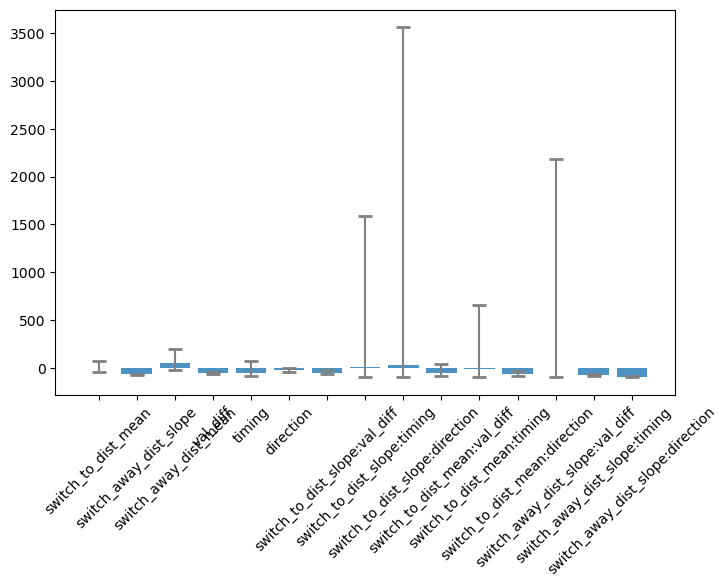

In [42]:
folder = output_path 
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(np.arange(1, 16, 1).flatten(), 100.0*pt[1:16], alpha=0.8)

# Add error bars
plt.errorbar(
    np.arange(1, 16, 1).flatten(), 100.0*pt[1:16], yerr=error_bars, fmt='none', ecolor='gray', capsize=5, capthick=2
)

tick_positions = np.arange(1, 16, 1)
tick_labels = [f'{i}' for i in design_matrix.columns[1:16].values]
plt.xticks(tick_positions, tick_labels, rotation=45)

output_file = folder / "GLM_behave_coeff_GLMM_bayes_all.svg"
plt.savefig(output_file, transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [43]:
# save table
#Save the table
with open(folder / "binomial_mixed_glm_results.txt", "w") as file:
    file.write(str(result.summary()))

In [46]:
# Extract the second table from the summary as plain text
summary_text = str(result.summary())
table_start = summary_text.find("Intercept")  # Start of the table
table_end = summary_text.find("subject") + len("subject")  # End of the table
table_text = summary_text[table_start:table_end]

# Convert the table text into rows
table_rows = [row.split() for row in table_text.splitlines()]

# Manually parse the rows into a DataFrame
columns = ["Variable", "Type", "Post. Mean", "Post. SD", "SD", "SD (LB)", "SD (UB)"]
df = pd.DataFrame(table_rows, columns=columns[:len(table_rows[0])])  # Adjust columns dynamically
df = df.drop(df.index[16])
df['sig'] = issig
df.to_csv(folder / "binomial_mixed_glm_results.csv", index=False)

np.savetxt(folder / 'binomial_mixed_percent.csv', np.vstack((pt,fixed_effects_sd)).transpose(), delimiter=',')

In [47]:
# Show complex choice landscapes
rwdlev = np.linspace(0, 1.00, 101)
switch_dist = np.linspace(GLM_data['switch_to_dist_mean'].min(),GLM_data['switch_to_dist_mean'].max(),101)
intercept = fixed_effects[0]
rwd_beta = fixed_effects[5]
switch_to_dist_beta = fixed_effects[1]
interaction = fixed_effects[7]

In [48]:
# Create a grid of all combinations of rwdlev and switch_dist
rwdlev_grid, switch_dist_grid = np.meshgrid(rwdlev, switch_dist)

In [49]:
# get predictions
# Compute the predicted outcome
y_pred = (
        intercept +
        rwd_beta * rwdlev_grid +
        switch_to_dist_beta * switch_dist_grid +
        interaction * (rwdlev_grid * switch_dist_grid)
)

y_pred=1/(1+np.exp(-y_pred))
levels = np.linspace(y_pred.min(), y_pred.max(), 50)

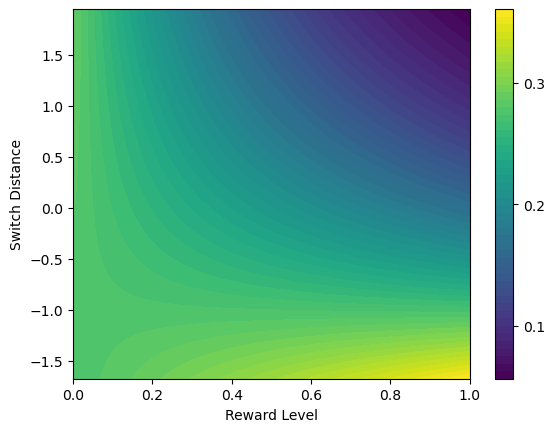

In [50]:
plt.contourf(rwdlev_grid, switch_dist_grid, y_pred, levels=levels, cmap="viridis")
# Define even tick spacing

# Round the maximum value to the nearest 0.1 for the colorbar
rounded_max = np.ceil(y_pred.max() * 10) / 10  # Rounds up to the nearest 0.1
rounded_min = np.floor(y_pred.min() * 10) / 10  # Rounds down to the nearest 0.1
tick_spacing = 0.1
ticks = np.arange(rounded_min, rounded_max + tick_spacing, tick_spacing)
# Add the colorbar with custom ticks
cbar = plt.colorbar(ticks=ticks)
cbar.ax.set_yticklabels([f"{tick:.1f}" for tick in ticks])  # Format tick labels to 1 decimal place
plt.xlabel("Reward Level")
plt.ylabel("Switch Distance")

output_file = folder / "GLM_behave_SwitchTo_ValDiff_interaction.svg"
plt.savefig(output_file, transparent=True, bbox_inches='tight', dpi=300)
plt.show()


In [51]:
rwdlev = np.linspace(0, 1.00, 3)
switch_dist = np.linspace(GLM_data['switch_away_dist_mean'].min(), GLM_data['switch_away_dist_mean'].max(), 101)
timing = np.linspace(GLM_data['timing'].min(), GLM_data['timing'].max(), 101)

timing_grid, switch_dist_grid = np.meshgrid(timing, switch_dist)

intercept = fixed_effects[0]
timing_beta = fixed_effects[6]
switch_to_dist_beta = fixed_effects[4]
interaction = fixed_effects[14]

y_pred = (
        intercept +
        timing_beta * timing_grid +
        switch_to_dist_beta * switch_dist_grid +
        interaction * (timing_grid * switch_dist_grid)
)

y_pred = 1 / (1 + np.exp(-y_pred))
levels = np.linspace(y_pred.min(), y_pred.max(), 50)

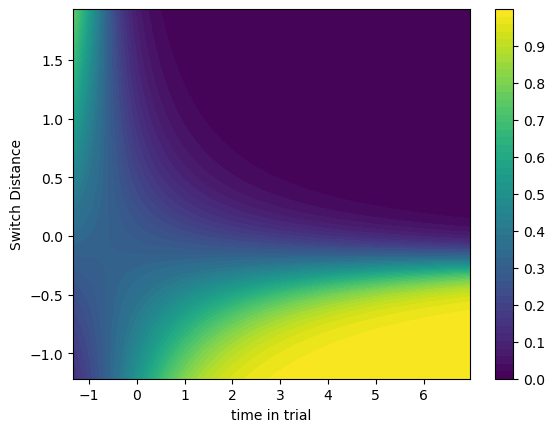

In [52]:
plt.contourf(timing_grid, switch_dist_grid, y_pred, levels=levels, cmap="viridis")

# Define even tick spacing
# Round the maximum value to the nearest 0.1 for the colorbar
rounded_max = np.ceil(y_pred.max() * 10) / 10  # Rounds up to the nearest 0.1
rounded_min = np.floor(y_pred.min() * 10) / 10  # Rounds down to the nearest 0.1
tick_spacing = 0.1
ticks = np.arange(rounded_min, rounded_max + tick_spacing, tick_spacing)
# Add the colorbar with custom ticks
cbar = plt.colorbar(ticks=ticks)
cbar.ax.set_yticklabels([f"{tick:.1f}" for tick in ticks])  # Format tick labels to 1 decimal place
plt.xlabel("time in trial")
plt.ylabel("Switch Distance")

output_file = folder / "GLM_behave_SwitchAway_Timing_interaction.svg"
plt.savefig(output_file, transparent=True, bbox_inches='tight', dpi=300)
plt.show()